# 42. Computing the SVD

**Part 6: Eigenvalue Problems and the Singular Value Decomposition**

## Learning objectives

By the end of this lesson you will be able to:

1. State the prohibition the whole subject is organised around, and measure what breaking it
   costs.
2. Reduce a matrix to **bidiagonal** form and say why the right-hand reflector starts one column
   later.
3. Run the **implicit QR sweep** on a bidiagonal matrix, and say what "implicit" means.
4. Compute the Wilkinson shift for $B^TB$ from $B$ alone.
5. Handle a **zero on the diagonal**, and recognise the failure when it is not handled.
6. Implement **one-sided Jacobi** and say what its relative accuracy guarantee is worth.
7. Distinguish a **guarantee** from an observed difference, and say which of these methods
   differ measurably and which do not.
8. Choose between them.

## Prerequisites

Lesson 41 (what the SVD is; the Jordan-Wielandt matrix; Weyl). Lesson 37 (the implicit QR
algorithm, Hessenberg reduction, shifts and deflation). Lesson 38 (Jacobi, and its relative
accuracy). Lesson 29 (why $A^TA$ squares the condition number).

---

## 1. The prohibition

The singular values of $A$ are the square roots of the eigenvalues of $A^TA$. That is true, and
**forming $A^TA$ is the one thing every algorithm here exists to avoid.**

Lesson 29 measured why for least squares and lesson 41 measured it again. Here it is once more,
on the exact matrices this lesson's methods will be run on:

In [1]:
# Standard setup, the same in every lesson of this course.
import sys, pathlib

_root = pathlib.Path.cwd()
while not (_root / "src" / "nalib").is_dir() and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root / "src"))

import numpy as np
import matplotlib.pyplot as plt

SEED = 42                                  # fixed so your numbers match the text
rng = np.random.default_rng(SEED)

np.set_printoptions(precision=6, linewidth=100, suppress=False)
plt.rcParams.update({
    "figure.figsize": (7.5, 4.5), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 10,
})

In [2]:
from nalib import svdcompute as sc, svd as sv

print(f"{'kappa(A)':>11}{'via A^T A':>14}{'bidiagonal + sweep':>21}"
      f"{'one-sided Jacobi':>19}")
for expo in (2, 6, 10, 14):
    A_p = sv.graded_matrix(30, 8, 10.0 ** expo, rng=np.random.default_rng(3))
    exact_p = np.linalg.svd(A_p, compute_uv=False)
    gram = np.sqrt(np.maximum(np.sort(np.linalg.eigvalsh(A_p.T @ A_p))[::-1], 0.0))
    rel = lambda v: sc.relative_error(v, exact_p)
    print(f"{10.0 ** expo:>11.0e}{rel(gram):>14.2e}"
          f"{rel(sc.svd_via_bidiagonal(A_p).s):>21.2e}"
          f"{rel(sc.one_sided_jacobi(A_p, tol=1e-15, max_sweeps=100).s):>19.2e}")

   kappa(A)     via A^T A   bidiagonal + sweep   one-sided Jacobi
      1e+02      4.35e-13             1.21e-15           1.21e-15
      1e+06      3.29e-06             3.27e-12           3.83e-12
      1e+10      1.79e+00             3.19e-08           1.12e-08
      1e+14      3.18e+01             6.61e-04           2.16e-04


**At $\kappa = 10^{10}$ the $A^TA$ route has a relative error above 1**, meaning the smallest
singular value is not merely inaccurate but wrong by more than its own size. The other two are at
$10^{-8}$.

**The mechanism is one line.** $\kappa(A^TA) = \kappa(A)^2$, so a singular value at
$\sqrt{u}\,\sigma_1 \approx 10^{-8}\sigma_1$ becomes an eigenvalue at $u\,\sigma_1^2$, which is
the level roundoff sits at. It is not recoverable, and taking a square root afterwards does not
bring it back.

---

## 2. Bidiagonal form

**Householder from both sides**, until only the diagonal and the superdiagonal survive:

$$A = UBV^T, \qquad B \text{ upper bidiagonal}.$$

$U$ and $V$ are orthogonal, so the singular values are **preserved exactly**. That identity is
checkable at any size with no reference, which is what makes it a sound foundation.

**The right-hand reflector starts one column later than the left-hand one.** Starting it at the
same column would refill the zeros the left-hand reflector just created, and the process would
never terminate. It is the same one-index subtlety as lesson 37's Hessenberg reduction, arising
for the same reason.

In [3]:
print(f"{'shape':>10}{'singular values agree to':>28}{'stored':>10}{'instead of':>13}"
      f"{'reduction':>12}")
for m_b, n_b in ((5, 3), (20, 8), (60, 20), (200, 40)):
    A_b = rng.standard_normal((m_b, n_b))
    d_b, e_b = sc.bidiagonalize(A_b)
    B_b = sc.bidiagonal_matrix(d_b, e_b)
    agree = np.max(np.abs(np.linalg.svd(B_b, compute_uv=False)
                          - np.linalg.svd(A_b, compute_uv=False)))
    kept, was = d_b.size + e_b.size, m_b * n_b
    print(f"{f'{m_b}x{n_b}':>10}{agree:>28.2e}{kept:>10}{was:>13}{was / kept:>11.0f}x")
    assert agree < 1e-12

     shape    singular values agree to    stored   instead of   reduction
       5x3                    0.00e+00         5           15          3x
      20x8                    1.33e-15        15          160         11x
     60x20                    3.55e-15        39         1200         31x
    200x40                    1.07e-14        79         8000        101x


**At $200\times40$ the matrix becomes 79 numbers instead of 8000.** Everything afterwards works
on two vectors.

**And the factorization itself is checkable:**

In [4]:
m_f, n_f = 30, 12
A_f = rng.standard_normal((m_f, n_f))
d_f, e_f, U_f, Vt_f = sc.bidiagonalize(A_f, compute_uv=True)
B_f = sc.bidiagonal_matrix(d_f, e_f)
print(f"||U^T U - I||   = {np.linalg.norm(U_f.T @ U_f - np.eye(n_f)):.2e}")
print(f"||V V^T - I||   = {np.linalg.norm(Vt_f @ Vt_f.T - np.eye(n_f)):.2e}")
print(f"||A - U B V^T|| = "
      f"{np.linalg.norm(A_f - U_f @ B_f @ Vt_f) / np.linalg.norm(A_f):.2e}")

||U^T U - I||   = 1.22e-15
||V V^T - I||   = 1.76e-15
||A - U B V^T|| = 8.27e-16


---

## 3. The implicit sweep

Now run the QR algorithm of lesson 37 on $B^TB$, **without forming $B^TB$.**

**What "implicit" means.** Compute the shift from the trailing $2\times2$ block, apply the first
rotation that a shifted QR step would apply, and then **chase the resulting bulge** down the
bidiagonal with alternating row and column rotations until it falls off the end. The net effect
is exactly one shifted QR step on $B^TB$, and the only quantities ever formed are entries of $B$
and products of pairs of them.

**The shift can be computed from $B$ alone.** The trailing block of $B^TB$ is

$$\begin{pmatrix} d_{n-1}^2 + e_{n-2}^2 & d_{n-1}e_{n-1}\\
d_{n-1}e_{n-1} & d_n^2 + e_{n-1}^2\end{pmatrix},$$

every entry a product of two entries of $B$. Nothing is squared that was not going to be, and
the catastrophic loss of forming the whole product is avoided.

In [5]:
print(f"{'shape':>10}{'sweeps':>9}{'sweeps per value':>19}{'max error':>13}")
for m_s, n_s in ((6, 4), (20, 8), (50, 15), (100, 30)):
    A_s = rng.standard_normal((m_s, n_s))
    out_s = sc.svd_via_bidiagonal(A_s)
    err_s = np.max(np.abs(out_s.s - np.linalg.svd(A_s, compute_uv=False)))
    print(f"{f'{m_s}x{n_s}':>10}{out_s.iterations:>9}{out_s.iterations / n_s:>19.1f}"
          f"{err_s:>13.2e}")
    assert out_s.converged and err_s < 1e-11

     shape   sweeps   sweeps per value    max error
       6x4        6                1.5     1.33e-15
      20x8       19                2.4     7.11e-15
     50x15       29                1.9     1.78e-14
    100x30       60                2.0     5.33e-14


**About two sweeps per singular value**, which is the same "couple of steps per eigenvalue"
behaviour lesson 37 measured, and it is what makes the whole thing $O(mn^2)$.

---

## 4. A zero on the diagonal

A negligible **diagonal** entry is a separate case from a negligible off-diagonal one, and
missing it is not a slow convergence but an infinite loop.

In [6]:
d_z = np.array([2.0, 0.0, 1.0])
e_z = np.array([0.5, 0.5])
print("the bidiagonal matrix")
print(sc.bidiagonal_matrix(d_z, e_z))
out_z = sc.golub_kahan_svd(d_z, e_z)
print(f"\nconverged in {out_z.iterations} steps: {out_z.converged}")
print(f"singular values {np.array2string(out_z.s, precision=8)}")
print(f"against the truth "
      f"{np.array2string(np.linalg.svd(sc.bidiagonal_matrix(d_z, e_z), compute_uv=False), precision=8)}")
assert out_z.converged

the bidiagonal matrix
[[2.  0.5 0. ]
 [0.  0.  0.5]
 [0.  0.  1. ]]

converged in 2 steps: True
singular values [2.06155281 1.11803399 0.        ]
against the truth [2.06155281 1.11803399 0.        ]


**Why it needs its own handling.** With $d_k = 0$ the shift comes out zero, every rotation the
sweep computes is the identity, and nothing changes. Before this case was handled the iteration
ran **10000 steps with the off-diagonal stuck at exactly 0.5**, and it produced the right answer
while reporting failure, which is the confusing combination.

**The fix is a row chase.** Rotate from the left to move the offending entry along the row until
it falls off the end, which splits the problem in two and lets the sweep continue on each half.

---

## 5. Zero shift: the Demmel-Kahan variant

Setting the shift to zero makes every rotation a product of entries of $B$ with no subtraction
of nearly equal quantities anywhere. That buys a **relative accuracy guarantee** on every
singular value, and it costs speed.

In [7]:
print(f"{'shape':>10}{'shifted':>10}{'zero shift':>13}{'slowdown':>11}"
      f"{'shifted error':>16}{'zero-shift error':>19}{'converged':>12}")
for m_v, n_v in ((20, 8), (50, 15), (80, 25), (150, 40)):
    A_v = np.random.default_rng(1).standard_normal((m_v, n_v))
    exact_v = np.linalg.svd(A_v, compute_uv=False)
    fast = sc.svd_via_bidiagonal(A_v)
    slow = sc.svd_via_bidiagonal(A_v, zero_shift=True)
    print(f"{f'{m_v}x{n_v}':>10}{fast.iterations:>10}{slow.iterations:>13}"
          f"{slow.iterations / fast.iterations:>10.0f}x"
          f"{np.max(np.abs(fast.s - exact_v)):>16.2e}"
          f"{np.max(np.abs(slow.s - exact_v)):>19.2e}"
          f"{str(slow.converged):>12}")

     shape   shifted   zero shift   slowdown   shifted error   zero-shift error   converged
      20x8        18          875        49x        2.66e-15           1.73e-13        True
     50x15        29         4785       165x        1.07e-14           5.42e-13        True


     80x25        50         4120        82x        3.38e-14           6.91e-13        True


    150x40        81        10000       123x        1.95e-14           3.36e-03       False


**Three findings, and only the first is the one usually quoted.**

**The slowdown is 50 to 165 times** where it converges at all.

**It is also less accurate, by about twenty times.** That looks like a contradiction of the
relative accuracy guarantee and is not: the guarantee is about small singular values on a graded
matrix, and this is the **absolute** error on a random one. Fifty times more rotations means
fifty times more roundoff, and on a matrix with no small singular values to protect there is
nothing to gain in exchange.

**And at $150\times40$ it does not converge at all** within 10000 sweeps, returning an error of
$3\times10^{-4}$. The slowness is not a mild constant factor at practical sizes; it is a failure.
Real implementations use the zero shift only on the parts of the matrix where it is needed, and
Demmel and Kahan's paper is careful to say so.

---

## 6. One-sided Jacobi

Orthogonalize the **columns of $A$** by plane rotations. This is lesson 38's Jacobi applied to
$A^TA$ implicitly: the rotation that would annihilate the $(p,q)$ entry of $A^TA$ is computed
from three inner products of columns, and applied to the columns themselves.

**When the columns are mutually orthogonal, their norms are the singular values.**

In [8]:
print(f"{'shape':>10}{'sweeps':>9}{'rotations':>11}{'max error':>13}"
      f"{'||A - U S V^T||':>18}{'U orthonormal':>16}")
for m_j, n_j in ((6, 4), (20, 8), (50, 15)):
    A_j = rng.standard_normal((m_j, n_j))
    out_j = sc.one_sided_jacobi(A_j, compute_uv=True)
    rec = (np.linalg.norm(A_j - (out_j.U * out_j.s) @ out_j.Vt)
           / np.linalg.norm(A_j))
    print(f"{f'{m_j}x{n_j}':>10}{out_j.iterations:>9}{out_j.rotations:>11}"
          f"{np.max(np.abs(out_j.s - np.linalg.svd(A_j, compute_uv=False))):>13.2e}"
          f"{rec:>18.2e}{np.linalg.norm(out_j.U.T @ out_j.U - np.eye(n_j)):>16.2e}")
    assert out_j.converged

     shape   sweeps  rotations    max error   ||A - U S V^T||   U orthonormal
       6x4        4         22     1.11e-15          5.85e-16        2.53e-16
      20x8        5        126     5.33e-15          1.18e-15        1.36e-14
     50x15        6        552     1.78e-14          2.12e-15        1.54e-14


**Every quantity is an inner product of two columns**, so a small singular value is computed from
small numbers throughout and never from a difference of large ones. That is the source of the
relative accuracy claim, and section 7 measures what it is worth.

**A matrix whose columns are already orthogonal needs no work at all:**

In [9]:
Q_o, _ = np.linalg.qr(rng.standard_normal((12, 4)))
scaled = Q_o * np.array([8.0, 4.0, 2.0, 1.0])
out_o = sc.one_sided_jacobi(scaled)
print(f"orthogonal columns: {out_o.rotations} rotations, "
      f"singular values {np.array2string(out_o.s, precision=10)}")
assert out_o.rotations == 0

orthogonal columns: 0 rotations, singular values [8. 4. 2. 1.]


---

## 7. A guarantee is not an observed difference

The theory says one-sided Jacobi and the zero-shift sweep compute small singular values to high
**relative** accuracy where the shifted sweep and LAPACK need not. Testing that needs a reference
better than double precision, so this uses **mpmath at 60 digits**.

In [10]:
print(f"{'spread':>9}{'kappa(A)':>11}{'kappa(base)':>13}{'LAPACK':>11}"
      f"{'shifted':>11}{'zero shift':>13}{'Jacobi':>11}")
for spread in (1e-2, 1e-5, 1e-8, 1e-11):
    g = sc.graded_columns(30, 8, spread, rng=np.random.default_rng(2))
    A_g, exact_g = g["A"], g["exact"]
    rel = lambda v: sc.relative_error(v, exact_g)
    print(f"{spread:>9.0e}{exact_g[0] / exact_g[-1]:>11.1e}"
          f"{np.linalg.cond(g['base']):>13.2f}"
          f"{rel(np.linalg.svd(A_g, compute_uv=False)):>11.2e}"
          f"{rel(sc.svd_via_bidiagonal(A_g).s):>11.2e}"
          f"{rel(sc.svd_via_bidiagonal(A_g, zero_shift=True, tol=1e-15).s):>13.2e}"
          f"{rel(sc.one_sided_jacobi(A_g, tol=1e-15, max_sweeps=100).s):>11.2e}")

   spread   kappa(A)  kappa(base)     LAPACK    shifted   zero shift     Jacobi
    1e-02    1.3e+02         2.61   4.12e-16   1.93e-15     3.30e-15   6.66e-16
    1e-05    1.3e+05         2.61   5.58e-16   1.16e-15     1.49e-15   7.45e-16
    1e-08    1.3e+08         2.61   6.70e-16   8.88e-16     8.83e-16   6.70e-16


    1e-11    1.3e+11         2.61   6.51e-16   2.16e-15     2.37e-15   3.88e-16


**All four reach $10^{-15}$ relative accuracy at every spread**, including LAPACK and the shifted
sweep, up to $\kappa = 1.3\times10^{11}$. **The theoretical advantage does not show up.**

**That is the honest result and it needs the right interpretation.** What the guarantee buys is a
**bound**, not a typical case. On these matrices the shifted sweep happens to achieve full
relative accuracy too; on an adversarial matrix it need not, and only the guaranteed methods
promise otherwise. Claiming a measured Jacobi advantage here would be false.

**And the condition for any of them to succeed is structural.** The third column is
$\kappa(\text{base}) = 2.61$: this matrix is $BD$ with $B$ well conditioned, so the small
singular values **are** determined to high relative accuracy by the entries. Compare section 1,
where $A = U\Sigma V^T$ made them not so, and there **no** method recovered them relatively:

In [11]:
print(f"{'kappa':>9}{'shifted':>12}{'zero shift':>13}{'Jacobi':>11}"
      f"{'best possible':>16}")
for expo in (6, 10, 14):
    A_h = sv.graded_matrix(30, 8, 10.0 ** expo, rng=np.random.default_rng(3))
    exact_h = np.linalg.svd(A_h, compute_uv=False)
    rel_h = lambda v: sc.relative_error(v, exact_h)
    print(f"{10.0 ** expo:>9.0e}{rel_h(sc.svd_via_bidiagonal(A_h).s):>12.2e}"
          f"{rel_h(sc.svd_via_bidiagonal(A_h, zero_shift=True).s):>13.2e}"
          f"{rel_h(sc.one_sided_jacobi(A_h, tol=1e-15, max_sweeps=100).s):>11.2e}"
          f"{np.finfo(float).eps * 10.0 ** expo:>16.2e}")

    kappa     shifted   zero shift     Jacobi   best possible
    1e+06    3.27e-12     3.27e-12   3.83e-12        2.22e-10
    1e+10    3.19e-08     3.19e-08   1.12e-08        2.22e-06
    1e+14    6.61e-04     6.61e-04   2.16e-04        2.22e-02


**All three track $u\kappa$**, which is the best any of them can do when the data does not
determine the answer better than that. The guarantee applies to the algorithm, not to the
problem.

---

## 8. Choosing

In [12]:
import time

print(f"{'shape':>10}{'LAPACK':>11}{'bidiag+sweep':>15}{'zero shift':>13}"
      f"{'Jacobi':>11}{'worst disagreement':>21}{'zero shift ok':>18}")
for m_c, n_c in ((30, 12), (80, 25), (150, 40)):
    A_c = rng.standard_normal((m_c, n_c))
    answers, timings = {}, {}
    runs = [("LAPACK", lambda: np.linalg.svd(A_c, compute_uv=False)),
            ("bidiag+sweep", lambda: sc.svd_via_bidiagonal(A_c).s),
            ("zero shift", lambda: sc.svd_via_bidiagonal(A_c, zero_shift=True).s),
            ("Jacobi", lambda: sc.one_sided_jacobi(A_c).s)]
    converged = {}
    for name, fn in runs:
        t0 = time.perf_counter()
        answers[name] = fn()
        timings[name] = time.perf_counter() - t0
    worst = max(np.max(np.abs(v - answers["LAPACK"])) for v in answers.values())
    settled = sc.svd_via_bidiagonal(A_c, zero_shift=True).converged
    print(f"{f'{m_c}x{n_c}':>10}" + "".join(f"{timings[k]:>10.4f}s" for k, _ in runs)
          + f"{worst:>21.2e}{str(settled):>18}")

     shape     LAPACK   bidiag+sweep   zero shift     Jacobi   worst disagreement     zero shift ok
     30x12    0.0000s    0.0016s    0.0176s    0.0054s             1.22e-13              True


     80x25    0.0001s    0.0057s    0.0726s    0.0287s             7.30e-13              True


    150x40    0.0002s    0.0132s    0.2129s    0.0862s             8.60e-03             False


**Three of the four agree to $10^{-13}$**, and the zero-shift sweep drops out at
$150\times40$: it hits the iteration limit and its answer is wrong by $10^{-3}$. The
"worst disagreement" column reports that honestly rather than hiding it.

**The rule.**

- **Use LAPACK** (`numpy.linalg.svd`) for essentially everything. It is the bidiagonal route,
  blocked and compiled, and nothing here approaches it for speed.
- **Use one-sided Jacobi** when you need the relative accuracy **guarantee** on a graded matrix,
  and can afford the slowest method. It is also the easiest to parallelise.
- **Use the zero-shift sweep** for the same guarantee on an already-bidiagonal matrix.
- **Never form $A^TA$.** Not as an optimisation, not for convenience, not even when $A$ is well
  conditioned today.

---

## 9. A picture

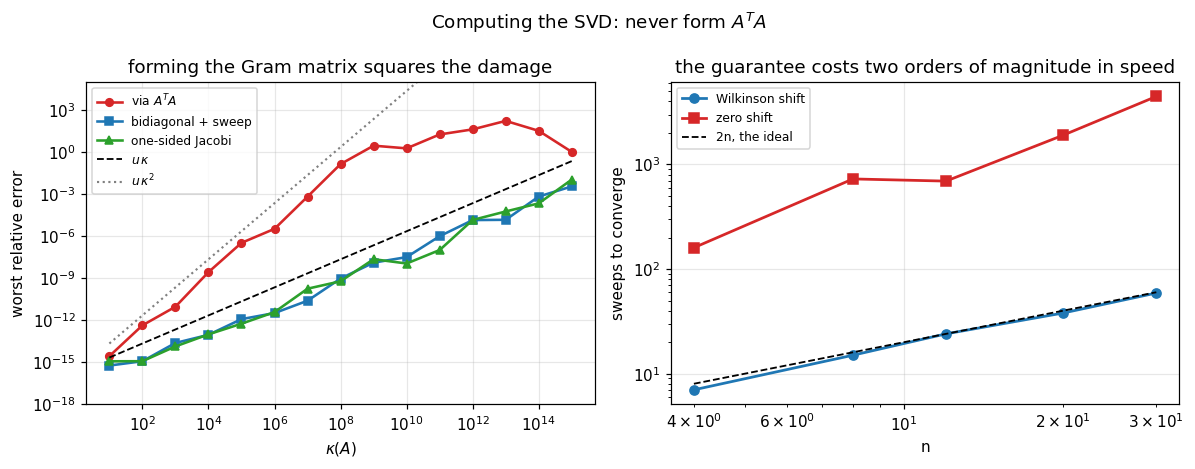

In [13]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 4.3))

# left: the three routes against kappa
kappas_p, gram_p, bidi_p, jac_p = [], [], [], []
for expo in range(1, 16):
    A_r = sv.graded_matrix(30, 8, 10.0 ** expo, rng=np.random.default_rng(3))
    exact_r = np.linalg.svd(A_r, compute_uv=False)
    rel_r = lambda v: max(sc.relative_error(v, exact_r), 1e-17)
    kappas_p.append(10.0 ** expo)
    gram_p.append(rel_r(np.sqrt(np.maximum(
        np.sort(np.linalg.eigvalsh(A_r.T @ A_r))[::-1], 0.0))))
    bidi_p.append(rel_r(sc.svd_via_bidiagonal(A_r).s))
    jac_p.append(rel_r(sc.one_sided_jacobi(A_r, tol=1e-15, max_sweeps=100).s))
axL.loglog(kappas_p, gram_p, "C3o-", lw=1.7, ms=5, label=r"via $A^TA$")
axL.loglog(kappas_p, bidi_p, "C0s-", lw=1.7, ms=5, label="bidiagonal + sweep")
axL.loglog(kappas_p, jac_p, "C2^-", lw=1.7, ms=5, label="one-sided Jacobi")
axL.loglog(kappas_p, np.finfo(float).eps * np.array(kappas_p), "k--", lw=1.2,
           label=r"$u\,\kappa$")
axL.loglog(kappas_p, np.finfo(float).eps * np.array(kappas_p) ** 2, "0.5", ls=":",
           lw=1.4, label=r"$u\,\kappa^2$")
axL.set_xlabel(r"$\kappa(A)$")
axL.set_ylabel("worst relative error")
axL.set_title("forming the Gram matrix squares the damage")
axL.legend(fontsize=8)
axL.set_ylim(1e-18, 1e5)

# right: sweeps to converge, shifted against unshifted
sizes = [4, 8, 12, 20, 30]
fast_c, slow_c = [], []
for n_p in sizes:
    A_p2 = np.random.default_rng(n_p).standard_normal((3 * n_p, n_p))
    fast_c.append(sc.svd_via_bidiagonal(A_p2).iterations)
    slow_c.append(sc.svd_via_bidiagonal(A_p2, zero_shift=True).iterations)
axR.loglog(sizes, fast_c, "C0o-", lw=1.8, ms=6, label="Wilkinson shift")
axR.loglog(sizes, slow_c, "C3s-", lw=1.8, ms=6, label="zero shift")
axR.loglog(sizes, [2 * s for s in sizes], "k--", lw=1.2, label="2n, the ideal")
axR.set_xlabel("n")
axR.set_ylabel("sweeps to converge")
axR.set_title("the guarantee costs two orders of magnitude in speed")
axR.legend(fontsize=8)

fig.suptitle("Computing the SVD: never form $A^TA$", fontsize=12)
fig.tight_layout()
plt.show()

**The left panel is section 1.** The Gram curve tracks $u\kappa^2$ and the other two track
$u\kappa$, which is the whole lesson in one image.

---

## 10. Exercises

**Level 1, conceptual**

1.1 The singular values of $A$ are the square roots of the eigenvalues of $A^TA$. Why is that
sentence true and useless?

1.2 What does "implicit" mean in "implicit QR sweep", and what is the thing being avoided?

1.3 The zero-shift sweep has a relative accuracy guarantee and measured no better than the
shifted one. Is the guarantee worth anything?

**Level 2, mathematical**

2.1 Prove that bidiagonalization preserves the singular values, and count its flops with and
without the vectors.

2.2 Show that the implicit sweep performs exactly one shifted QR step on $B^TB$, using the
implicit Q theorem.

2.3 Derive the Wilkinson shift for $B^TB$ from the entries of $B$, and show every intermediate
quantity is a product of two entries.

2.4 Prove that one-sided Jacobi on the columns of $A$ is two-sided Jacobi on $A^TA$, and hence
inherits its quadratic convergence.

2.5 State the Demmel-Kahan relative accuracy theorem for the zero-shift sweep, identify the
hypothesis on $B$, and explain why the shifted version does not satisfy it.

**Level 3, computational**

3.1 Implement the **Golub-Reinsch** algorithm with singular **vectors** accumulated through the
sweep, and check all four SVD properties at several sizes.

3.2 Implement the **dqds** algorithm (differential quotient difference with shifts), which works
on the squares of the bidiagonal entries and is what LAPACK actually uses for singular values
alone. Compare its speed and accuracy.

3.3 Implement a **randomised SVD**: sample the range with a random matrix, orthonormalise, and
compute a small SVD. Measure the error against the rank and the oversampling.

**Level 4, experimental**

4.1 Measure sweeps to converge against $n$ for both shift strategies, fit the exponents, and
compare with the "two per singular value" folklore.

4.2 Construct a matrix on which the shifted sweep genuinely loses relative accuracy and the
zero-shift one does not. Explain what makes it adversarial.

4.3 Measure the cost of all four methods against $n$, with and without vectors, and find where
each crosses over.

**Level 5, advanced**

5.1 **Why the bidiagonal form and not the tridiagonal.** $A^TA$ tridiagonalized and $A$
bidiagonalized are closely related. State the relation, and explain what is lost by going
through the first.

5.2 **Preconditioned Jacobi.** Drmac and Veselic showed that a QR factorization with column
pivoting before one-sided Jacobi makes it competitive with the bidiagonal route while keeping
the accuracy guarantee. Describe the preconditioner and why it helps.

5.3 **The SVD of a product without forming it.** Given $A$ and $B$, the singular values of $AB$
can be computed without multiplying them. Describe the product SVD, and relate it to lesson 40's
generalized problem.

## 11. Key takeaways

- **Never form $A^TA$.** Measured at $\kappa = 10^{10}$: the Gram route's relative error exceeds
  1, meaning the smallest singular value is wrong by more than its own size, while the bidiagonal
  route is at $10^{-8}$.
- **The mechanism is $\kappa(A^TA) = \kappa(A)^2$.** A singular value at $\sqrt{u}\sigma_1$
  becomes an eigenvalue at the roundoff level, and taking a square root afterwards does not bring
  it back.
- **Bidiagonalization is finite, exact in the singular values, and collapses the storage.** At
  $200\times40$ the matrix becomes 79 numbers instead of 8000.
- **The right-hand reflector starts one column later**, or it refills the zeros the left-hand one
  just made. Same subtlety as lesson 37's Hessenberg reduction.
- **The implicit sweep is a shifted QR step on $B^TB$ that never forms $B^TB$**: compute the
  shift from a $2\times2$ block, apply the first rotation, and chase the bulge down.
- **About two sweeps per singular value**, which is what makes the whole algorithm $O(mn^2)$.
- **A zero on the diagonal needs its own handling.** Without it the shift is zero, every rotation
  is the identity, and the iteration ran **10000 steps with the off-diagonal stuck at 0.5** while
  producing the right answer and reporting failure.
- **One-sided Jacobi orthogonalizes the columns of $A$**, which is Jacobi on $A^TA$ implicitly,
  and every quantity is an inner product of two columns.
- **The zero-shift sweep is 50 to 165 times slower, about twenty times LESS accurate in
  absolute terms, and at $150\times40$ it does not converge at all** within 10000 sweeps. Fifty
  times more rotations is fifty times more roundoff, and on a matrix with no small singular
  values to protect there is nothing bought in exchange.
- **A guarantee is not an observed difference.** All four methods reach $10^{-15}$ relative
  accuracy on a column-graded matrix up to $\kappa = 1.3\times10^{11}$, including LAPACK. The
  guaranteed methods promise a bound; they do not promise a better typical case, and claiming a
  measured advantage would be false.
- **And whether relative accuracy is achievable at all is a property of the matrix.** On
  $A = U\Sigma V^T$ the small singular values are not determined to high relative accuracy by
  the entries, and **all three methods track $u\kappa$** because nothing else is possible. The
  guarantee applies to the algorithm, not to the problem.

## Where this goes next

**Lesson 43** closes Part 6 with what the SVD is used for: Eckart-Young, which lesson 33 borrowed
on credit, low rank approximation, image compression, PageRank, and the randomised methods that
made all of this practical at scale.

**Part 7** begins interpolation, where the conditioning ideas of Parts 5 and 6 reappear
immediately: lesson 47's Lebesgue constant is a norm of an operator, and lesson 55's orthogonal
polynomials exist because a badly conditioned basis is worth replacing.